# Onboarding Data Project

Fitz Koch  
2026-06-12

# Overview

The point of this project is to get some basic familiarity with `qmd` files, `duckdb`, and `SQL` if you don’t already have any.

Please complete this project in order. Spend no more than 12-15 hours on it unless you’re having a blast or answering questions that are really interesting to you. You’re getting paid to learn something!

## Rules:

-   Remember: the point is learning and ownership. This project is not for a grade, it’s for you to get ready for the summer, learn a lot, have fun, and hopefully build a resume. You’ll get paid either way, so make the time worth something to yourself.
-   **DO NOT** copy and paste anything from AI, or use any AI learning tool directly.
-   **FEEL FREE** to ask AI any questions, carefully read its answers, including reading functions that it wrote, and then reimplement them, or the logic behind them, in your code.
-   Have fun!

# Steps

## 0: Repo Setup

1.  Create a github repository named `[your_name]-okemo-data`.
2.  Make the repo public, and share it with me.
3.  Add a README, explaining what the project is, if you haven’t already, and commit it.

For all future steps, `git commit` at the end of every step where it makes sense. Include a message saying what you’ve done. At the end of each section, git rebase and squash, add, and push. Ask an LLM about what `rebase` is and why it’s useful.

## 1: Code setup

Note, all of the below is operating system sensitive. Feel free to ask AI to help you with it – but do the steps yourself, and pay attention to what’s going on!

1.  Get a package manager of some sort: `conda` or `uv`.
2.  Create a python environment with `duckdb` in it. Add whatever else you need when you need it.
3.  Download `quarto` and get it connected to your terminal.
4.  If you don’t already, get an IDE code editor (VS code, X Code, Sublime, etc.)
    -   If you’re married to VIM, or whatever, that’s okay, so long as it doesn’t disrupt your work. Note that vscode has a VIM method.
5.  Add ruff. It won’t work in `quarto`, but you need to do it sometime.
    -   install it if you haven’t already
    -   add a `.toml` with your ruff specifications
    -   Add a separate `playground`

## 2: Data Engineering

1.  Get a dataset from [kaggle](https://www.kaggle.com/) or somewhere like it.
2.  Create a `Data` folder and store the data in there. Make sure you specify that it is `raw`.
3.  Create a folder for your `.qmd` files and create an `engineering.qmd` file in it.
4.  Create a `yaml` header for your Quarto document. Look at the code in this repository for some ideas.
5.  Start coding! Begin by moving to the root and importing with code like this:

In [1]:
import os
from pathlib import Path
import duckdb

_project_root = Path.cwd()
while not (_project_root / ".git").exists():
    _project_root = _project_root.parent
    if _project_root == _project_root.parent:
        raise RuntimeError(".git not found — are you inside the repo?")
os.chdir(_project_root)
print(os.getcwd())

/home/fitsl/workbench/verso_okemo_onboarding

Write, in plain text, what this code does, above it. Do this for all future cells. You don’t have to go super detailed. Explain like I’m curious but not technical. Note that the code in this is turned off due to the `yaml` piece at the beginning (see the code for details).

If this code doesn’t make sense you or doesn’t work, just use `os.chdir("dir")` to your repo root. Note that code can hang on the above, so if things are taking a long time, that’s a likely culprit.

1.  Get the dataset into memory using `pandas`.
2.  Do the same using `duckdb`. You will have to use code that looks something like:

In [2]:
from pathlib import Path 

path = Path("Data/info.parquet")
con = duckdb.connect()
con.execute(f"""
  CREATE OR REPLACE VIEW zoning AS 
  SELECT * FROM read_parquet('{path}')
""")
df = con.execute("SELECT * FROM zoning").df()
df.head()

Note that the code instead the strings `con.execute(" ")` is `sql`. If you don’t know any `sql`, watch a youtube video, or ask an AI, or whatever helps you learn. It’s designed to be readable, but it can still be tricky sometimes. SQL keywords are generally in all-caps, and table/var names are in lower-case.

1.  Using both pandas and SQL, show that you know how to examine the data:
    -   get the names of the columns (hint, use SQLs “DESCRIBE”)
    -   get the unique value counts for one or two of the columns
    -   clean or reformat the data in some way. If nothing jumps out to you that can be cleaned, just doing something random (split columns, add a dummy variable, pivot form long to wide, etc.)
    -   discuss your general sense of the data
    -   make a few basic plots using `matplotlib` or `seaborn`. Nothing fancy, and very low level and summarizing.

Remember to articulate before each cell block what you want and expect it to do. If you’re better at one language or the other, do that first and then work from that as an example.

1.  Split the data into separate `.parquet` files by first creating views or tables using some portions of the columns, then save those views to parquet files. Make sure you don’t overwrite your existing data files; these are your *clean* tables. Use easily parseable names.

What’s the meaningful difference between an SQL view and a table? Why would we want one or the other? Put your answer in plain text in your `qmd`.

## 3. Data Analysis and Report

1.  Create a new `report.qmd` file with the same initial structure (yaml, root, imports) as `engineering.qmd`.
2.  Make a `db` connection to your three parquet files. Name them after what you parse in.
3.  Now you get to actually ask some questions of your data. Pick two or three things you’re genuinely curious about. Before each cell, write in plain text what question you’re asking and what you expect to find. Then write code to answer it, getting the data both with `pandas` and with `SQL`. Note if there are any places that one or the other seems more or less difficult. Some ideas:
    -   group by a category and compare averages, counts, or sums across groups
    -   filter down to an interesting subset and see how it differs from the whole

Example to see the number of rows for each value in a column `District_Name`:

In [3]:
df = con.execute("""--sql
  SELECT 
    District_Name as District,
    COUNT(*) AS Count,
  FROM zoning 
  GROUP BY District_Name
  ORDER BY COUNT(*) DESC
  LIMIT 15
""").df()
df.head()

1.  Make a few plots that tell a story. Use `matplotlib` or `seaborn`. Aim for 2-4 plots that each make a point. For each one:
    -   say in plain text what the plot is meant to show *before* you make it
    -   give it a real title, axis labels, and legend
    -   write a sentence or two *after* it on what you actually see, and whether it matched what you expected

Example plot to visualize the above:

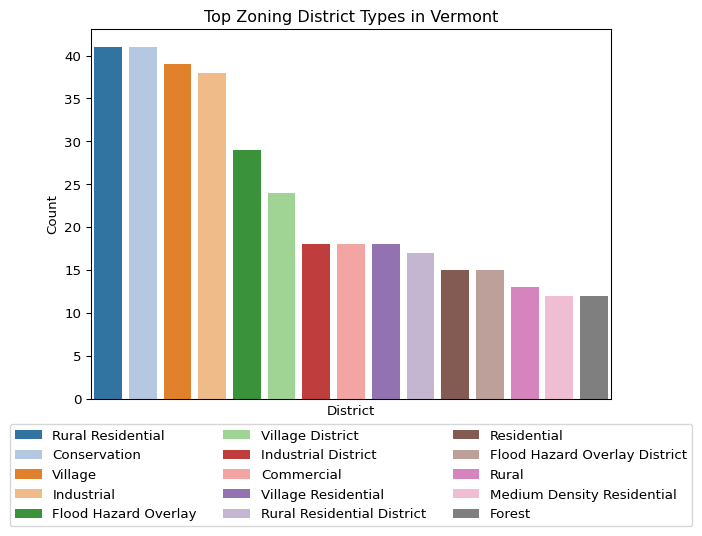

In [4]:
import seaborn as sns 
import matplotlib.pyplot as plt 

fig, ax = plt.subplots()
sns.barplot(data=df, x="District", y="Count", hue="District", ax=ax, palette="tab20", legend=True)
plt.title("Top Zoning District Types in Vermont")
ax.set_xticks([])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.show()

1.  Write a short conclusion. What did you learn about the data? What would you look at next if you had more time? What surprised you? No need to dazzle here, just be honest and clearly communicative.

## 4. Publish

The goal is a small `github.io` website with your rendered `.qmd` pages, plus a downloadable `pdf` of your report.

1.  Add a `_quarto.yml` project file at the root that builds a website. Look at Quarto’s [website docs](https://quarto.org/docs/websites/) – you want a `project: type: website` and a navbar linking your `engineering.qmd` and `report.qmd` pages. Ask AI to explain any field you don’t recognize, then write it yourself. See the `_quarto_yml` in this repo if you get stuck.
2.  Configure your `report.qmd` to also render to `pdf`. You’ll add `format:` with both `html` and `pdf` to its yaml header. You may need a LaTeX install – `quarto install tinytex` is the easy path. Add a link on your site so people can download the pdf. If this proves impossible, that’s also fine.
3.  Render the whole site locally with `quarto render` and open it in your browser. Fix anything that looks broken. Make sure code, plots, and the pdf link all work.
4.  Publish to GitHub Pages. The simplest way is to go to `settings` in github browser, then `pages`, then `deploy from a branch`. Read what it prints; it’ll tell you your `https://[your_name].github.io/[your_name]-okemo-data` URL.
5.  Put that live URL at the top of your repo’s `README`, and share it with me.